## Student Performance Indicator

### Life Cycle Of Machine Learning Project

1. Understanding the Problem Statement
2. Data Collection
3. Data Checks perform
4. Exploratory Data Analysis
5. Data Preprocessing
6. Model training
7. Choose Best Model

### 1. Problem Statement

* This project understand how the student's performance is affected by other variables such as Gender, Ethnicity, Parental Level of Education, Lunch and Test Preparation Course.

### 2. Data Collection

* Dataset Source: [Students Performance in Exams](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)


### 2.1 Import Data And required Libraries

```python


In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import parallel_coordinates
from matplotlib.lines import Line2D
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

In [102]:
df = pd.read_csv('data/stud.csv')

# constants used across plots
GENDER_ORDER = ['female', 'male']
GENDER_COLORS = ["#1f77b4", "#ff7f0e"]
SCORE_COLS = ["math_score", "reading_score", "writing_score", "average_score"]
PC_FEATURES = ["math_score", "reading_score", "writing_score", "average_score"]


In [103]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### 3. Data Checks perform

* missing values
* duplicate values
* data types
* Number of Unique values in each column
* statistical measures
* Various categories present in the different categorical columns

### 3.1 Missing values


In [104]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

**No missing values** in the dataset.

### 3.2 Duplicate values

In [105]:
df.duplicated().sum()

0

**No duplicate values** in the dataset.

### 3.3 Data types

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [107]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print("Numeric Features :", end=' ')
print(len(numeric_features), end='\n')
print("Categorical Features :", end=' ')
print(len(categorical_features))

Numeric Features : 3
Categorical Features : 5


### 3.4 Number of Unique values in each column

In [108]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

### 3.5 Statistical Measures

In [109]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


* Mean: 66.089 - 68.054
* Standard Deviation: 14.163 - 15.195
    * Math: 0 - 100
    * Reading: 17 - 100
    * Writing: 10 - 100

### 3.7 Exploring Data 

In [110]:
title = "Unique Values in Categorical Columns"
width = max(60, len(title) + 8)
print("\n" + "=" * width)
print(title.upper().center(width))
print("=" * width)

print("Gender :", end=' ')
print(df['gender'].unique(), end='\n')

print('Race Ethnicity :', end=' ')
print(df['race_ethnicity'].unique())

print('Parental Education :', end=' ')
print(df['parental_level_of_education'].unique())

print('Lunch :', end=' ')
print(df['lunch'].unique())

print('Test Preparation Course :', end=' ')
print(df['test_preparation_course'].unique())


            UNIQUE VALUES IN CATEGORICAL COLUMNS            
Gender : ['female' 'male']
Race Ethnicity : ['group B' 'group C' 'group A' 'group D' 'group E']
Parental Education : ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Lunch : ['standard' 'free/reduced']
Test Preparation Course : ['none' 'completed']


### 4. Feature Engineering
* total_score
* average_score
* grade

> pass Mark 33

In [111]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average_score'] = df['total_score'] / 3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [112]:
math_full = df[df['math_score'] == 100]['average_score'].count()
writing_full = df[df['writing_score'] == 100]['average_score'].count()
reading_full = df[df['reading_score'] == 100]['average_score'].count()

title = "Max Scores Achieved"
width = max(60, len(title) + 8)
print("\n" + "=" * width)
print(title.upper().center(width))
print("=" * width)

print("Number of Students with Full Math Score:", end=' ')
print(math_full, end='\n')
print("Number of Students with Full Writing Score:", end=' ')
print(writing_full, end='\n')
print("Number of Students with Full Reading Score:", end=' ')
print(reading_full)


                    MAX SCORES ACHIEVED                     
Number of Students with Full Math Score: 7
Number of Students with Full Writing Score: 14
Number of Students with Full Reading Score: 17


In [113]:
math_less = df[df['math_score'] < 33]['average_score'].count()
writing_less = df[df['writing_score'] < 33]['average_score'].count()
reading_less = df[df['reading_score'] < 33]['average_score'].count()

title = "Scores Below Passing Mark"
width = max(60, len(title) + 8)
print("\n" + "=" * width)
print(title.upper().center(width))
print("=" * width)

print("Number of Students with Math Score Below pass mark:", end=' ')
print(math_less, end='\n')
print("Number of Students with Writing Score Below pass mark:", end=' ')
print(writing_less, end='\n')
print("Number of Students with Reading Score Below pass mark:", end=' ')
print(reading_less)


                 SCORES BELOW PASSING MARK                  
Number of Students with Math Score Below pass mark: 19
Number of Students with Writing Score Below pass mark: 12
Number of Students with Reading Score Below pass mark: 11


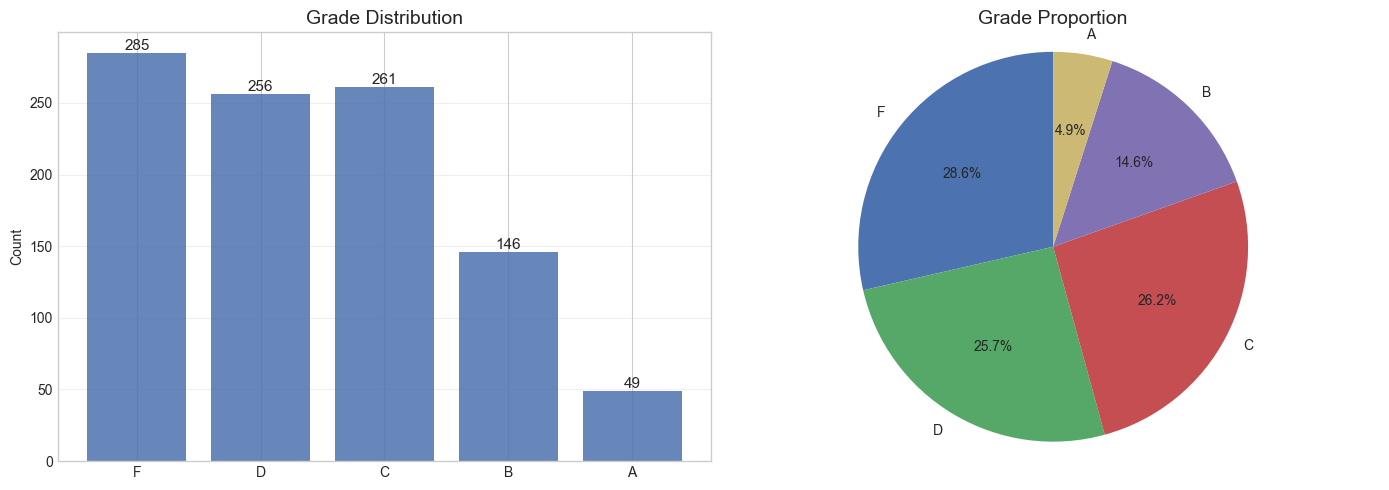

In [114]:
grade_bins = [0, 60, 70, 80, 90, 100]
grade_labels = ['F', 'D', 'C', 'B', 'A']
df['grade'] = pd.cut(df['average_score'], bins=grade_bins, labels=grade_labels, include_lowest=True, right=False)
grade_counts = df['grade'].value_counts().reindex(grade_labels)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars = axes[0].bar(grade_labels, grade_counts.values, color='#4c72b0', alpha=0.85)
axes[0].set_title('Grade Distribution', fontsize=14)
axes[0].set_ylabel('Count')
axes[0].bar_label(bars, fmt='%d', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)
axes[1].pie(grade_counts.values, labels=grade_labels, autopct='%1.1f%%', startangle=90, colors=['#4c72b0', '#55a868', '#c44e52', '#8172b3', '#ccb974'])
axes[1].set_title('Grade Proportion', fontsize=14)
axes[1].axis('equal')
plt.tight_layout()
plt.show()

### 5. Data Visualization

- From Feature Engineering we have created new features `total_score`, `average_score`
- Student West Performance in `Math`
- Student Bast Performance in `Reading`

### 5.1 Visualize distribution by Gender

- Histogram
- Kernel Density Estimate (KDE) Plot

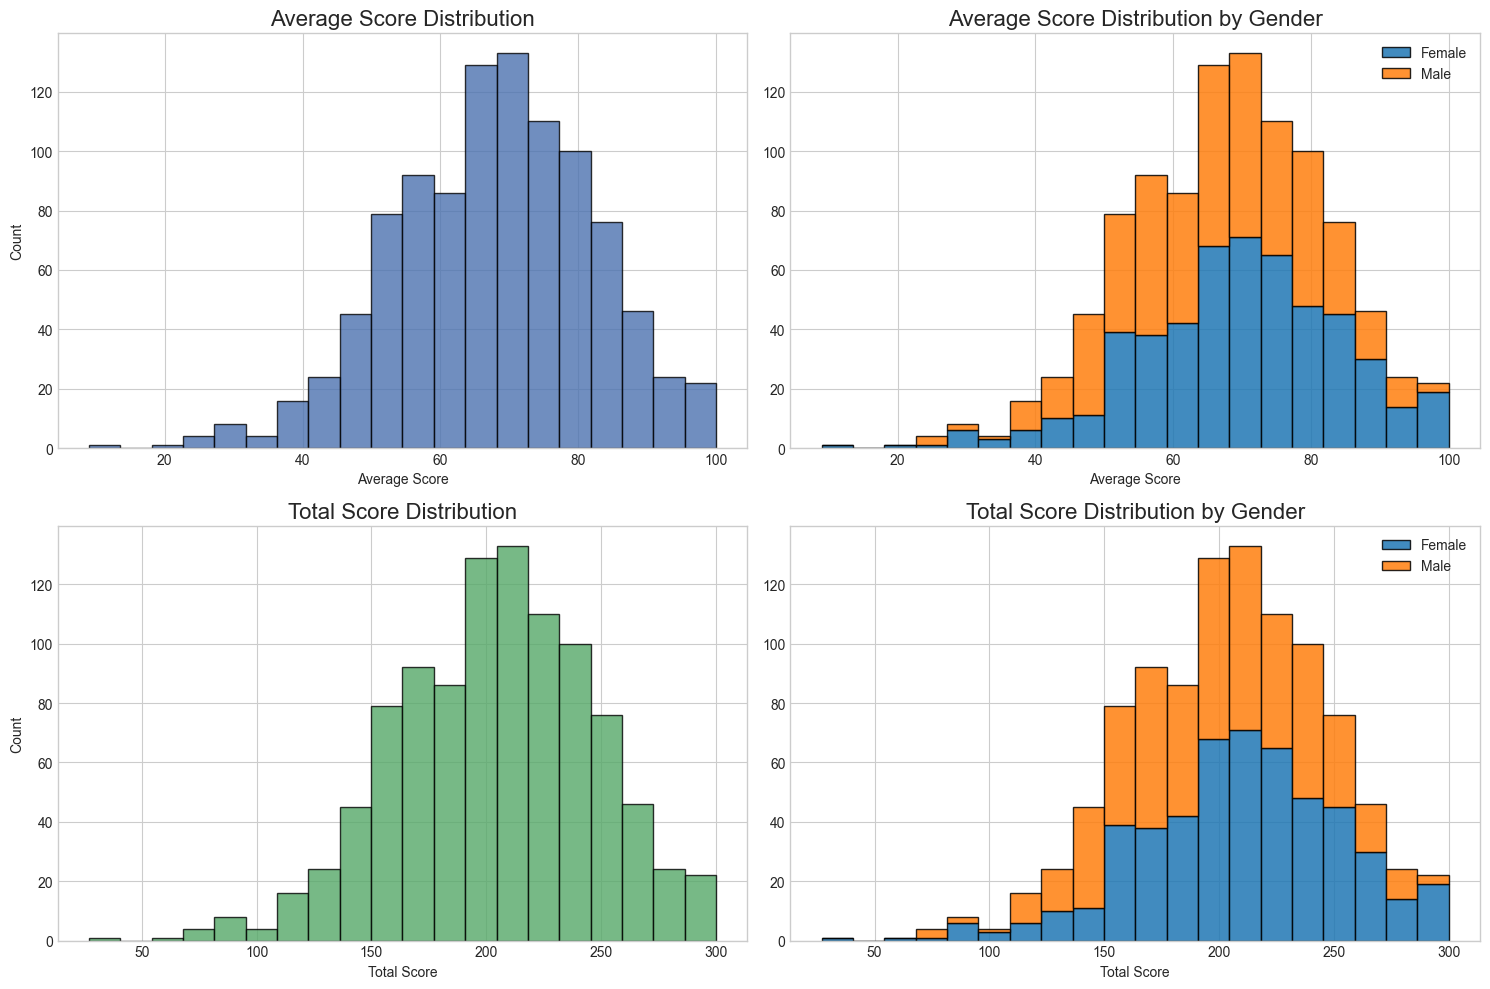

In [115]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

axs[0, 0].hist(df['average_score'], bins=20, color='#4c72b0', alpha=0.8, edgecolor='black')
axs[0, 0].set_title('Average Score Distribution', size=16)
axs[0, 0].set_xlabel('Average Score')
axs[0, 0].set_ylabel('Count')

axs[0, 1].hist(
    [df[df['gender'] == g]['average_score'] for g in GENDER_ORDER],
    bins=20,
    color=GENDER_COLORS,
    stacked=True,
    label=[g.title() for g in GENDER_ORDER],
    edgecolor='black',
    alpha=0.85
)
axs[0, 1].set_title('Average Score Distribution by Gender', size=16)
axs[0, 1].set_xlabel('Average Score')
axs[0, 1].legend()

axs[1, 0].hist(df['total_score'], bins=20, color='#55a868', alpha=0.8, edgecolor='black')
axs[1, 0].set_title('Total Score Distribution', size=16)
axs[1, 0].set_xlabel('Total Score')
axs[1, 0].set_ylabel('Count')

axs[1, 1].hist(
    [df[df['gender'] == g]['total_score'] for g in GENDER_ORDER],
    bins=20,
    color=GENDER_COLORS,
    stacked=True,
    label=[g.title() for g in GENDER_ORDER],
    edgecolor='black',
    alpha=0.85
)
axs[1, 1].set_title('Total Score Distribution by Gender', size=16)
axs[1, 1].set_xlabel('Total Score')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

> Female students have higher average and total scores than male students.

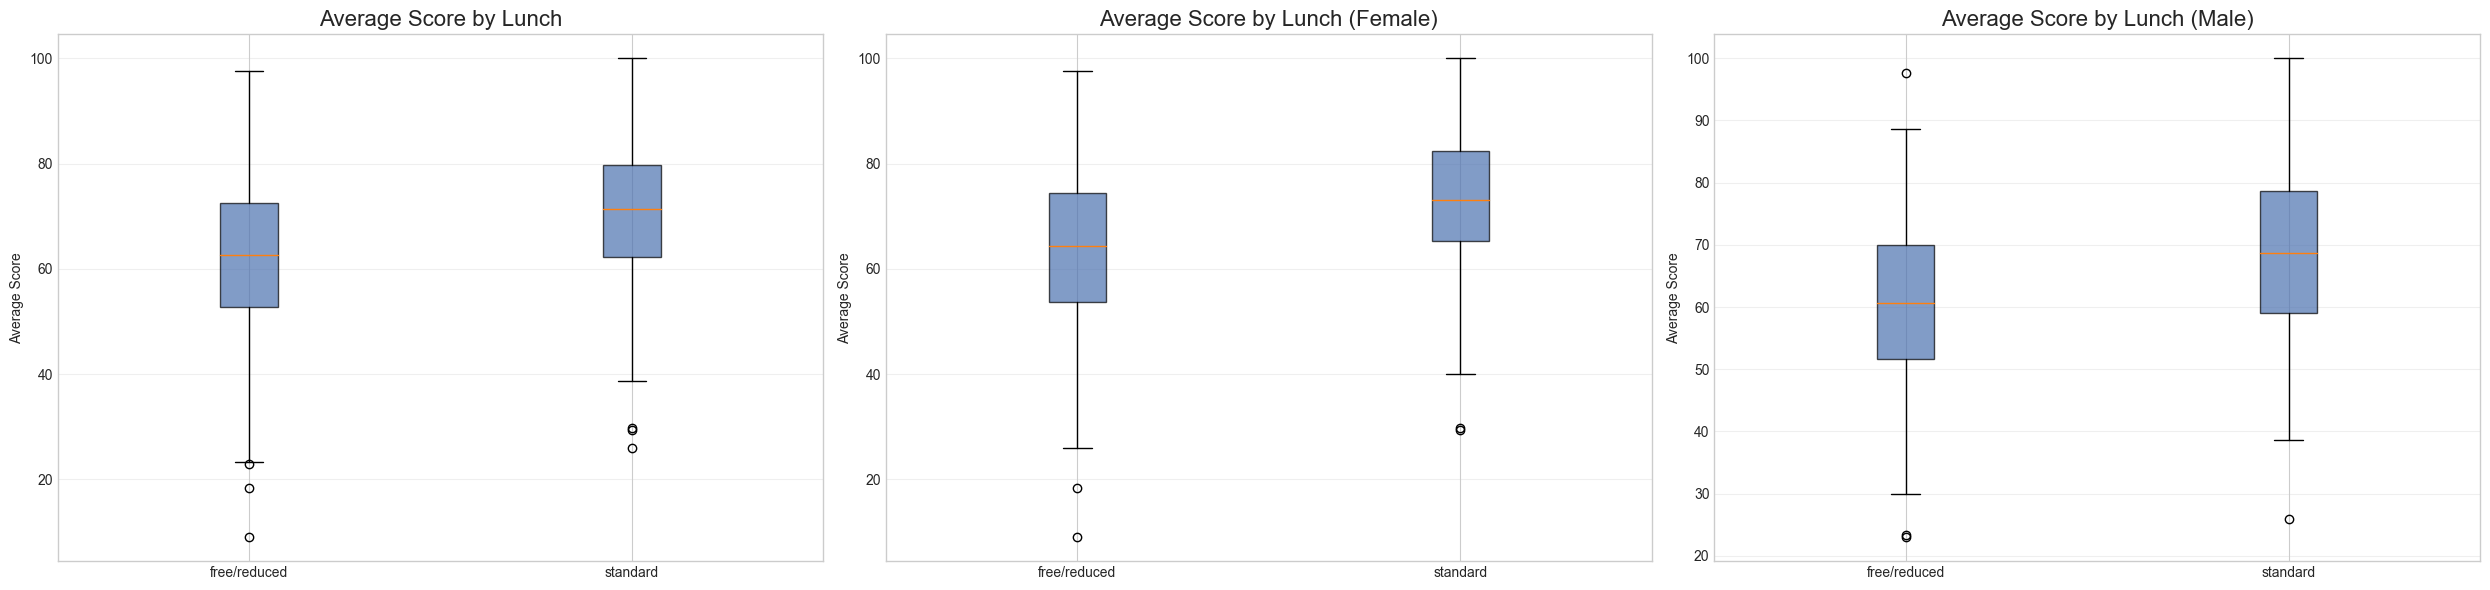

In [116]:
fig, axes = plt.subplots(1, 3, figsize=(25, 6))

for ax, subset, title in zip(
    axes,
    [df, df[df['gender'] == 'female'], df[df['gender'] == 'male']],
    ['Average Score by Lunch', 'Average Score by Lunch (Female)', 'Average Score by Lunch (Male)']
):
    groups = subset.groupby('lunch')['average_score'].apply(list)
    labels = groups.index.tolist()
    data = [groups[l] for l in labels]
    bp = ax.boxplot(data, labels=labels, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('#4c72b0')
        patch.set_alpha(0.7)
    ax.set_title(title, fontsize=16)
    ax.set_ylabel('Average Score')
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

> Standard lunch helps Perform better in Exams.

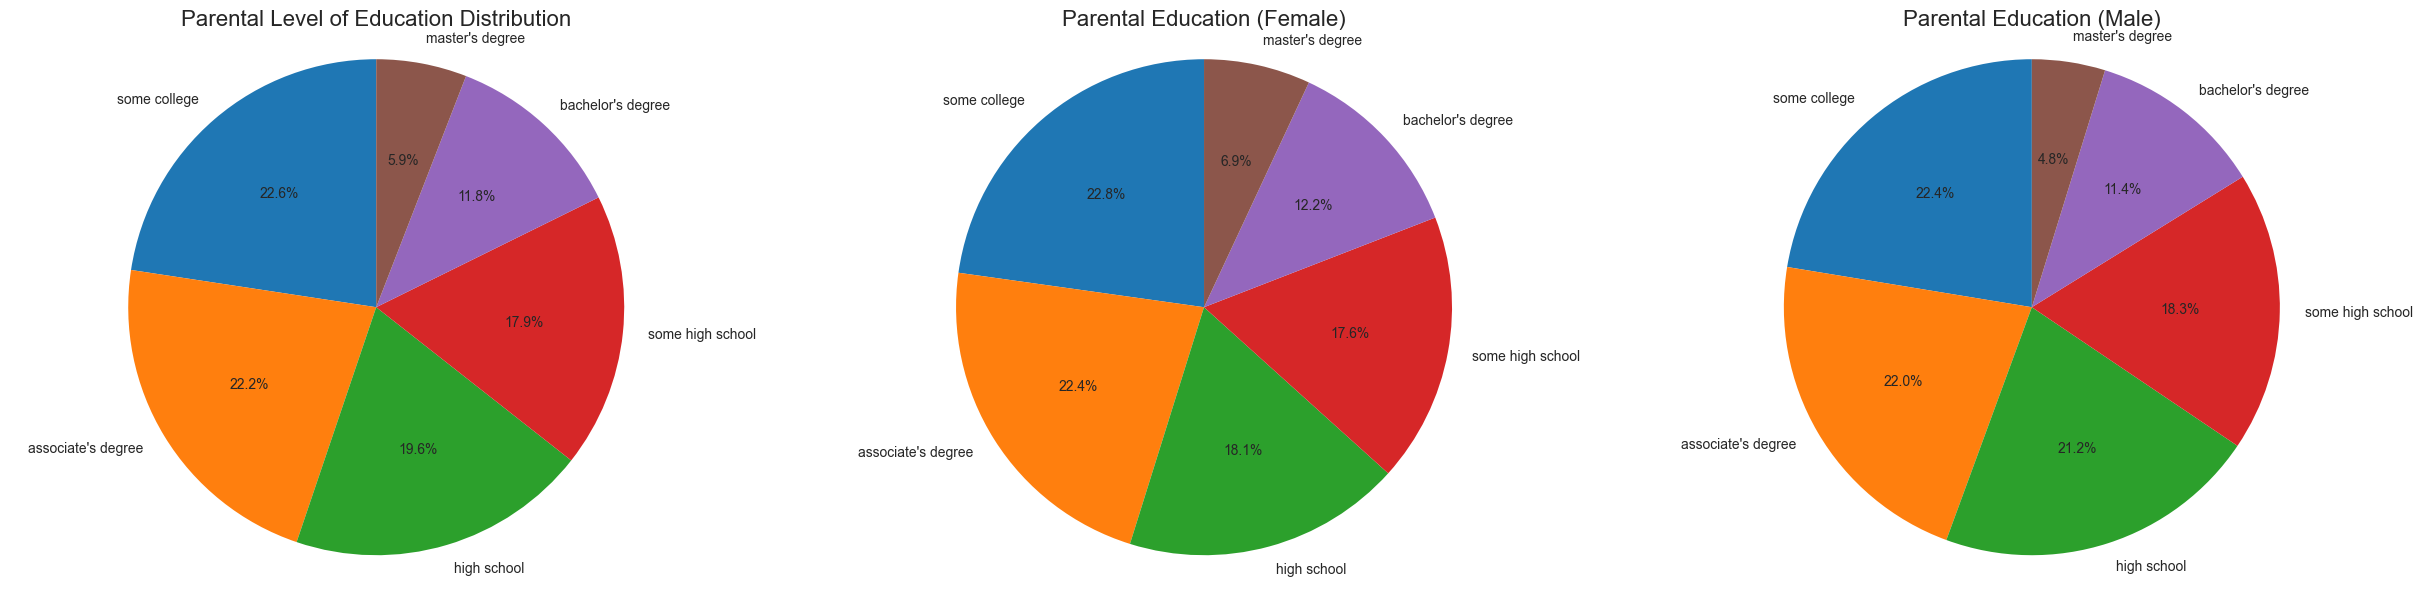

In [117]:
fig, axs = plt.subplots(1, 3, figsize=(25, 6))

parent_counts = df['parental_level_of_education'].value_counts()
female_counts = df[df['gender'] == 'female']['parental_level_of_education'].value_counts().reindex(parent_counts.index, fill_value=0)
male_counts = df[df['gender'] == 'male']['parental_level_of_education'].value_counts().reindex(parent_counts.index, fill_value=0)

axs[0].pie(parent_counts, labels=parent_counts.index, autopct='%1.1f%%', startangle=90)
axs[0].set_title('Parental Level of Education Distribution', fontsize=16)
axs[0].axis('equal')

axs[1].pie(female_counts, labels=parent_counts.index, autopct='%1.1f%%', startangle=90)
axs[1].set_title('Parental Education (Female)', fontsize=16)
axs[1].axis('equal')

axs[2].pie(male_counts, labels=parent_counts.index, autopct='%1.1f%%', startangle=90)
axs[2].set_title('Parental Education (Male)', fontsize=16)
axs[2].axis('equal')
plt.tight_layout()
plt.show()

> Most of the parents have completed `Associate's degree` and `College degree`.

### 5.2 Multivariate analysis

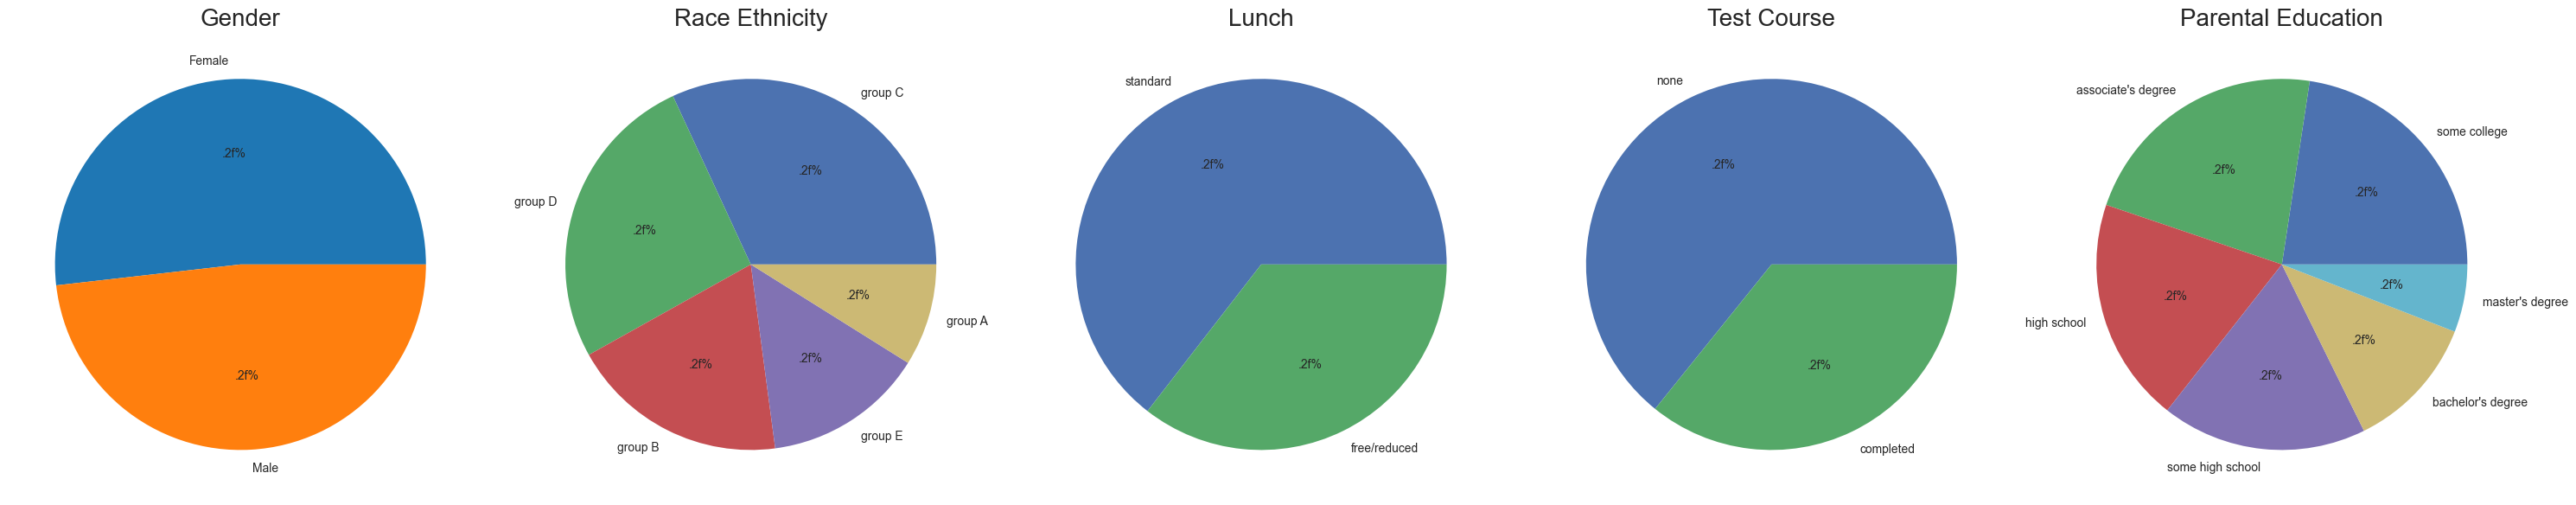

In [118]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = ['Female', 'Male']
color = ['#1f77b4', '#ff7f0e']
plt.pie(size, colors=color, labels=labels, autopct='.2f%%')
plt.title('Gender', fontsize=20)
plt.axis('off')

plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()
labels = size.index
color = ['#4c72b0', '#55a868', '#c44e52', '#8172b3', '#ccb974']
plt.pie(size, colors=color, labels=labels, autopct='.2f%%')
plt.title('Race Ethnicity', fontsize=20)
plt.axis('off')

plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = size.index
color = ['#4c72b0', '#55a868']
plt.pie(size, colors=color, labels=labels, autopct='.2f%%')
plt.title('Lunch', fontsize=20)
plt.axis('off')

plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = size.index
color = ['#4c72b0', '#55a868']
plt.pie(size, colors=color, labels=labels, autopct='.2f%%')
plt.title('Test Course', fontsize=20)
plt.axis('off')

plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
labels = size.index
color = ['#4c72b0', '#55a868', '#c44e52', '#8172b3', '#ccb974', '#64b5cd']
plt.pie(size, colors=color, labels=labels, autopct='.2f%%')
plt.title('Parental Education', fontsize=20)
plt.axis('off')

plt.tight_layout()
plt.grid()
plt.show()

- Female and male counts are nearly balanced.
- Group C has the highest representation; Group A is the smallest.
- Most students take standard lunch; test prep enrollment is lower.
- Parental education peaks at Some College and Associate's Degree.

### 6. Feature-Wise Visualization

- **Univariate:** inspect distributions and balance.
- **Bivariate:** check relationships and potential bias.
- **Multivariate:** combine features to see joint effects.

### 6.1 Gender Distribution

1) How is gender distributed in the dataset?
2) Does gender affect student performance?

#### 6.1.1 Gender distribution

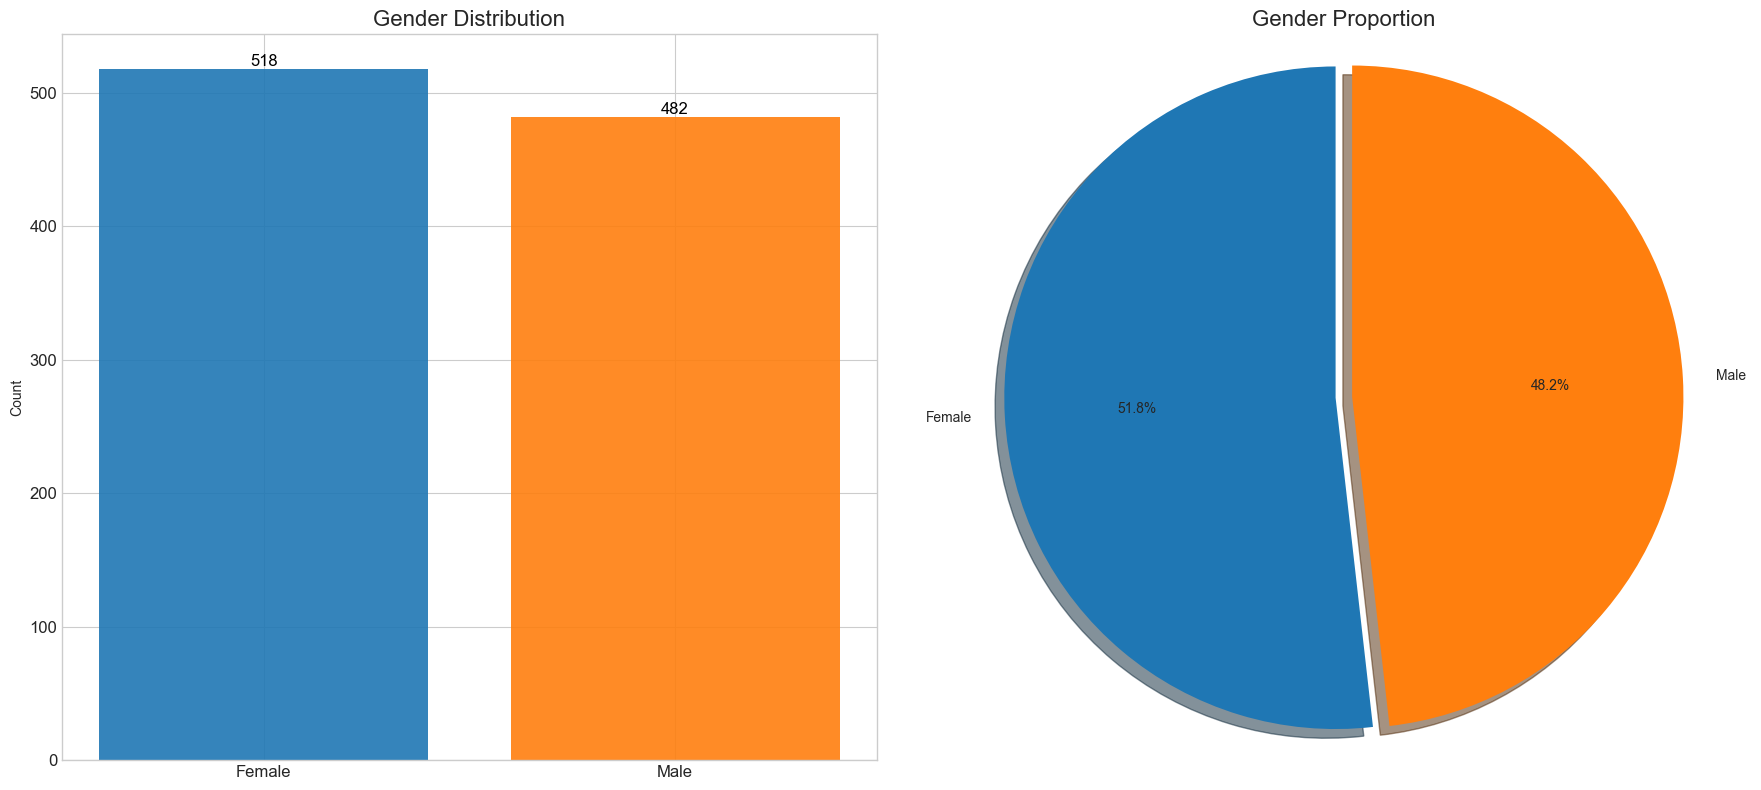

In [119]:
gender_order = ['female', 'male']
gender_palette = ["#1f77b4", "#ff7f0e"]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

counts = df['gender'].value_counts().reindex(gender_order)
x = np.arange(len(gender_order))
bars = axes[0].bar(x, counts.values, color=gender_palette, alpha=0.9)
axes[0].set_title('Gender Distribution', fontsize=16)
axes[0].set_xticks(x)
axes[0].set_xticklabels([g.title() for g in gender_order])
axes[0].set_ylabel('Count')
axes[0].tick_params(labelsize=12)
axes[0].bar_label(bars, fmt='%d', fontsize=12, color='black')

axes[1].pie(
    counts.values,
    labels=[g.title() for g in gender_order],
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05, 0],
    shadow=True,
    colors=gender_palette
)
axes[1].set_title('Gender Proportion', fontsize=16)
axes[1].axis('equal')

plt.tight_layout()
plt.show()

> Gender distribution is balanced, so downstream comparisons are not skewed by sample size.

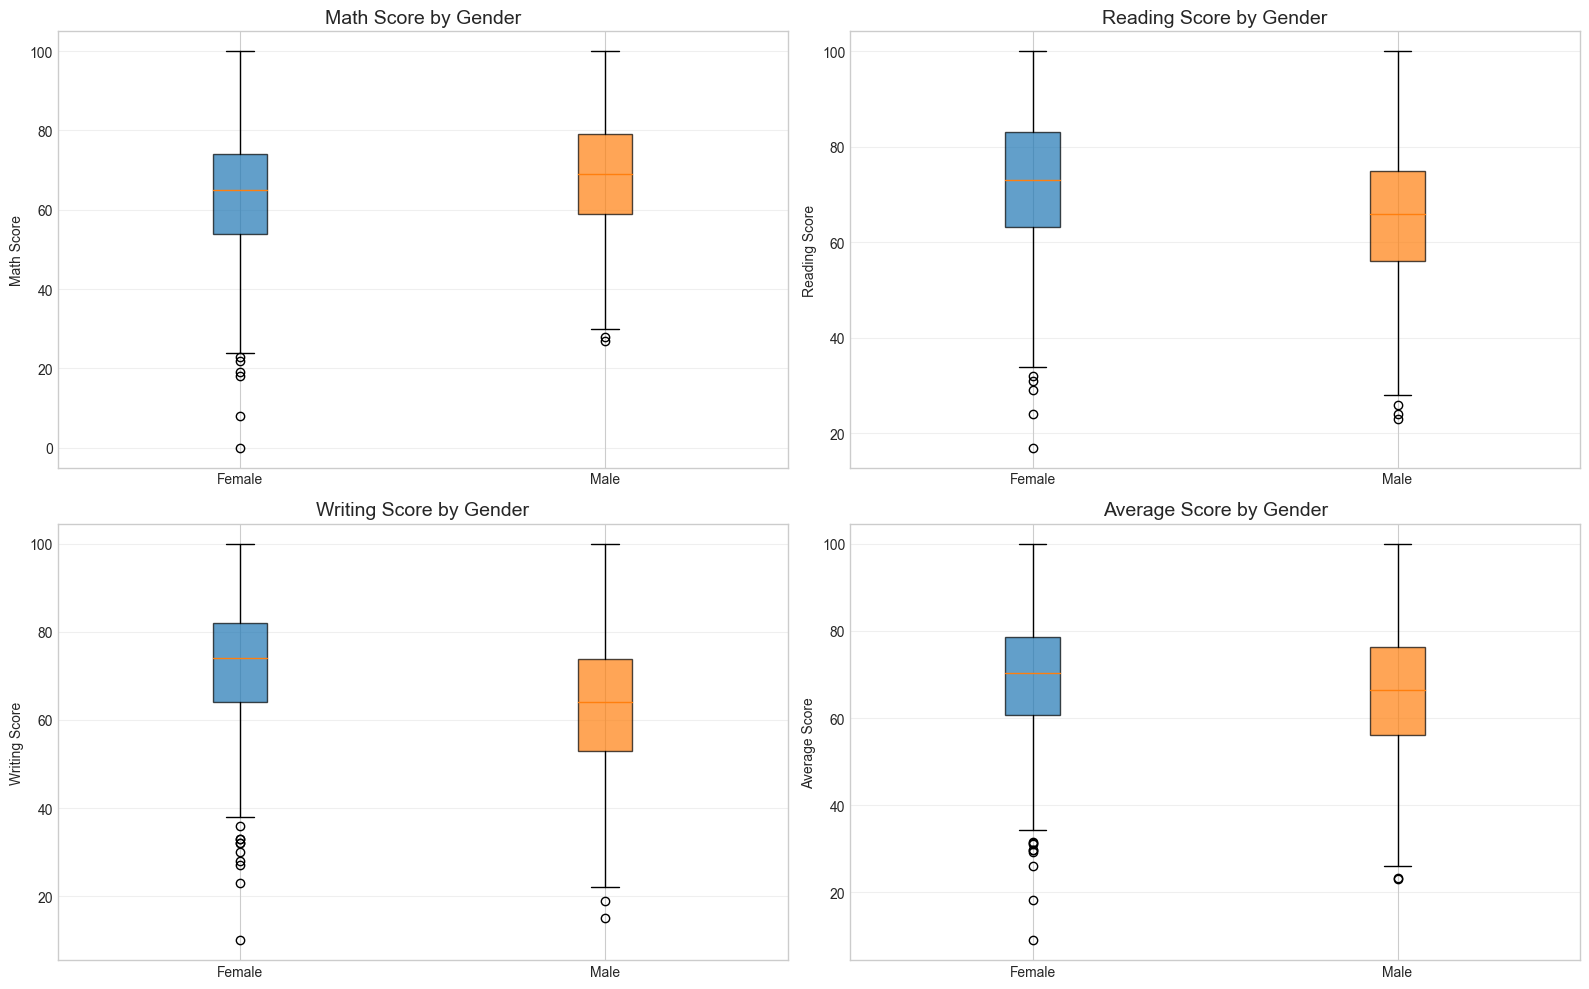

In [120]:
score_cols = ["math_score", "reading_score", "writing_score", "average_score"]
gender_order = ['female', 'male']
gender_palette = ["#1f77b4", "#ff7f0e"]

fig_gender, axes_gender = plt.subplots(2, 2, figsize=(16, 10))

for ax_plot, col in zip(axes_gender.flat, score_cols):
    data_by_gender = [df[df['gender'] == g][col].values for g in gender_order]
    bp = ax_plot.boxplot(data_by_gender, labels=[g.title() for g in gender_order], patch_artist=True)
    for patch, color in zip(bp['boxes'], gender_palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax_plot.set_title(f"{col.replace('_', ' ').title()} by Gender", fontsize=14)
    ax_plot.set_ylabel(col.replace('_', ' ').title())
    ax_plot.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

> Female students lead in reading, writing, and overall averages; males edge ahead slightly in math.

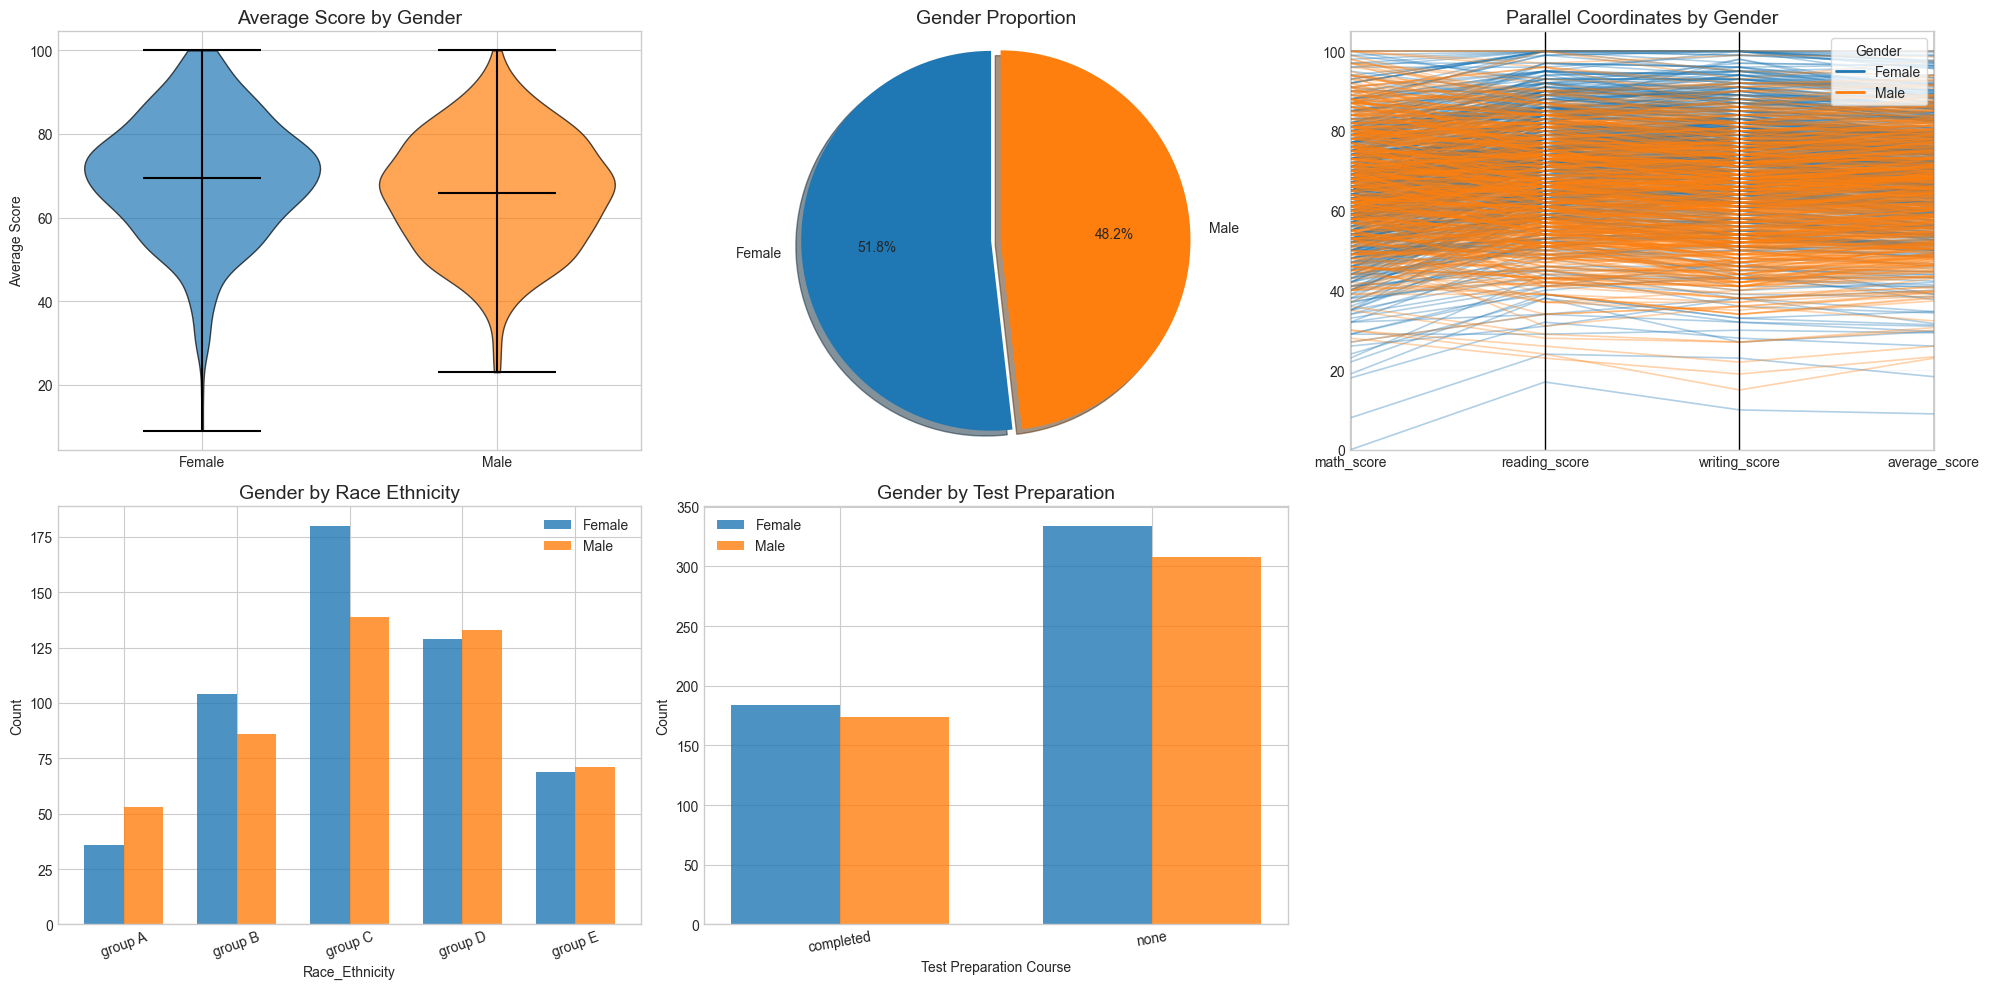

In [121]:
pc_features = PC_FEATURES
parallel_data = df[pc_features + ["gender"]].copy()
parallel_data["gender"] = pd.Categorical(parallel_data["gender"], categories=GENDER_ORDER, ordered=True)
parallel_data.sort_values(by="gender", inplace=True)  # type: ignore
gender_counts = df['gender'].value_counts().reindex(GENDER_ORDER)

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for gender_idx, gender in enumerate(GENDER_ORDER):
    vals = df[df['gender'] == gender]['average_score'].values
    parts = axes[0, 0].violinplot(vals, positions=[gender_idx], showmeans=True, showextrema=True, widths=0.8)
    for pc in parts['bodies']:
        pc.set_facecolor(GENDER_COLORS[gender_idx])
        pc.set_edgecolor('black')
        pc.set_alpha(0.7)
    for key in ('cbars', 'cmins', 'cmaxes', 'cmeans'):
        if key in parts:
            for line in np.atleast_1d(parts[key]):
                line.set_color('black')
axes[0, 0].set_xticks(range(len(GENDER_ORDER)))
axes[0, 0].set_xticklabels([g.title() for g in GENDER_ORDER])
axes[0, 0].set_title('Average Score by Gender', fontsize=14)
axes[0, 0].set_ylabel('Average Score')

axes[0, 1].pie(
    gender_counts.values,
    labels=[g.title() for g in GENDER_ORDER],
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05, 0],
    shadow=True,
    colors=GENDER_COLORS
)
axes[0, 1].set_title('Gender Proportion', fontsize=14)
axes[0, 1].axis('equal')

parallel_coordinates(
    parallel_data,
    class_column='gender',
    cols=pc_features,
    color=GENDER_COLORS,
    ax=axes[0, 2],
    linewidth=1.2,
    alpha=0.35
)
axes[0, 2].set_ylim(0, 105)
axes[0, 2].grid(True, axis='y', alpha=0.15)
axes[0, 2].set_title('Parallel Coordinates by Gender', fontsize=14)
legend_handles = [Line2D([0], [0], color=c, lw=2, label=g.title()) for g, c in zip(GENDER_ORDER, GENDER_COLORS)]
axes[0, 2].legend(handles=legend_handles, title='Gender', loc='upper right', frameon=True)

race_counts = df.groupby(['race_ethnicity', 'gender']).size().unstack(fill_value=0).reindex(columns=GENDER_ORDER)
race_x = np.arange(len(race_counts.index))
width = 0.35
axes[1, 0].bar(race_x - width/2, race_counts[GENDER_ORDER[0]], width, label=GENDER_ORDER[0].title(), color=GENDER_COLORS[0], alpha=0.8)
axes[1, 0].bar(race_x + width/2, race_counts[GENDER_ORDER[1]], width, label=GENDER_ORDER[1].title(), color=GENDER_COLORS[1], alpha=0.8)
axes[1, 0].set_xticks(race_x)
axes[1, 0].set_xticklabels(race_counts.index, rotation=20)
axes[1, 0].set_title('Gender by Race Ethnicity', fontsize=14)
axes[1, 0].set_xlabel('Race_Ethnicity')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()

test_counts = df.groupby(['test_preparation_course', 'gender']).size().unstack(fill_value=0).reindex(columns=GENDER_ORDER)
test_x = np.arange(len(test_counts.index))
axes[1, 1].bar(test_x - width/2, test_counts[GENDER_ORDER[0]], width, label=GENDER_ORDER[0].title(), color=GENDER_COLORS[0], alpha=0.8)
axes[1, 1].bar(test_x + width/2, test_counts[GENDER_ORDER[1]], width, label=GENDER_ORDER[1].title(), color=GENDER_COLORS[1], alpha=0.8)
axes[1, 1].set_xticks(test_x)
axes[1, 1].set_xticklabels(test_counts.index, rotation=10)
axes[1, 1].set_title('Gender by Test Preparation', fontsize=14)
axes[1, 1].set_xlabel('Test Preparation Course')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()

axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

> Female students show stronger correlations among scores than males, especially between reading and writing.

#### 6.1.2 Race Ethnicity
- Univariate: distribution balance across groups.
- Bivariate: score dispersion by group.
- Multivariate: race with gender and test prep.

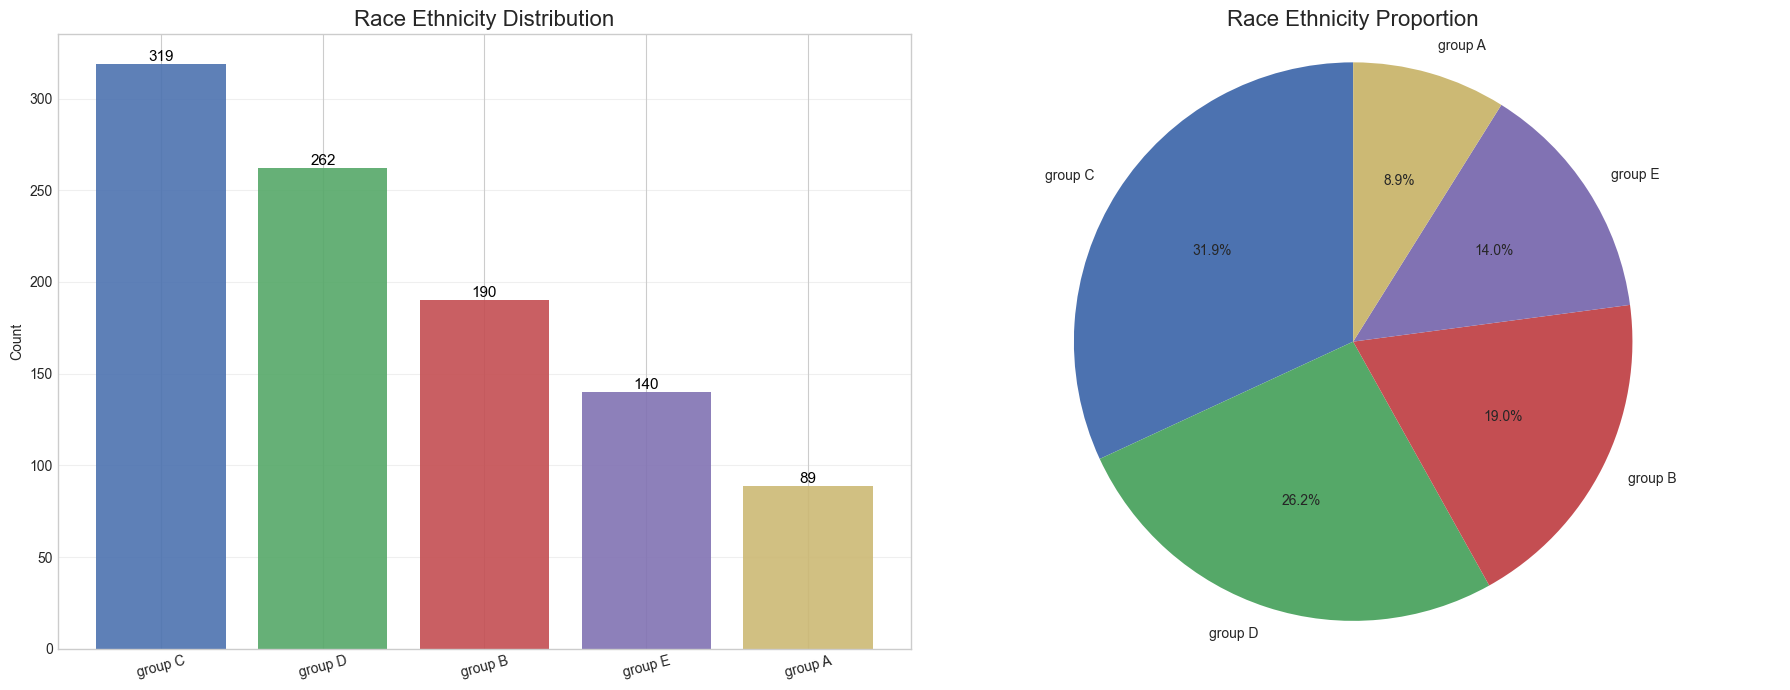

In [122]:
race_counts = df['race_ethnicity'].value_counts()
race_order = race_counts.index.tolist()
race_colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b3', '#ccb974'][:len(race_order)]
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
x = np.arange(len(race_order))
bars = axes[0].bar(x, race_counts.values, color=race_colors, alpha=0.9)
axes[0].set_title('Race Ethnicity Distribution', fontsize=16)
axes[0].set_xticks(x)
axes[0].set_xticklabels(race_order, rotation=15)
axes[0].set_ylabel('Count')
axes[0].bar_label(bars, fmt='%d', fontsize=11, color='black')
axes[0].grid(axis='y', alpha=0.3)
axes[1].pie(race_counts.values, labels=race_order, autopct='%1.1f%%', startangle=90, colors=race_colors)
axes[1].set_title('Race Ethnicity Proportion', fontsize=16)
axes[1].axis('equal')
plt.tight_layout()
plt.show()

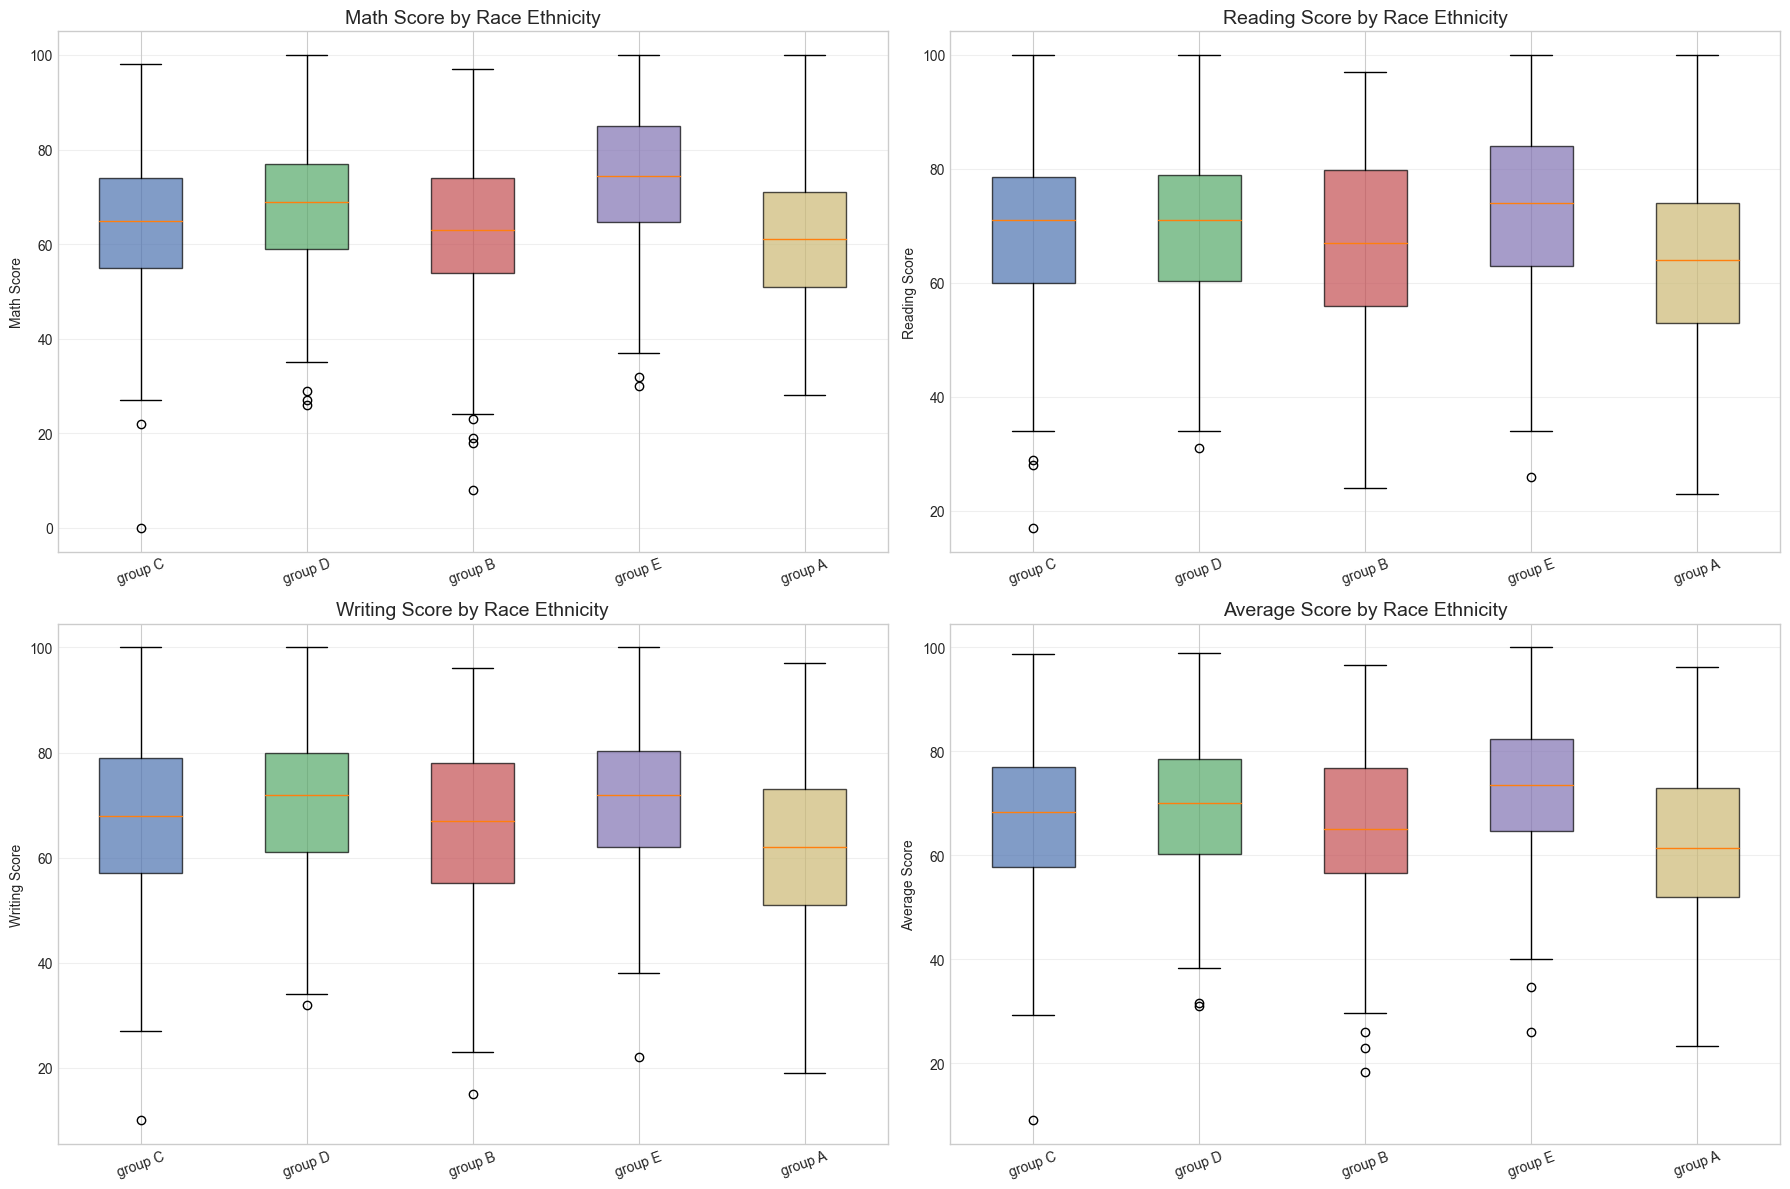

In [123]:
score_cols = SCORE_COLS
race_order = df['race_ethnicity'].value_counts().index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax_plot, col in zip(axes.flat, score_cols):
    grouped = [df[df['race_ethnicity'] == r][col].values for r in race_order]
    bp = ax_plot.boxplot(grouped, labels=race_order, patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#4c72b0', '#55a868', '#c44e52', '#8172b3', '#ccb974'][:len(race_order)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax_plot.set_title(f"{col.replace('_', ' ').title()} by Race Ethnicity", fontsize=14)
    ax_plot.set_ylabel(col.replace('_', ' ').title())
    ax_plot.tick_params(axis='x', rotation=20)
    ax_plot.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

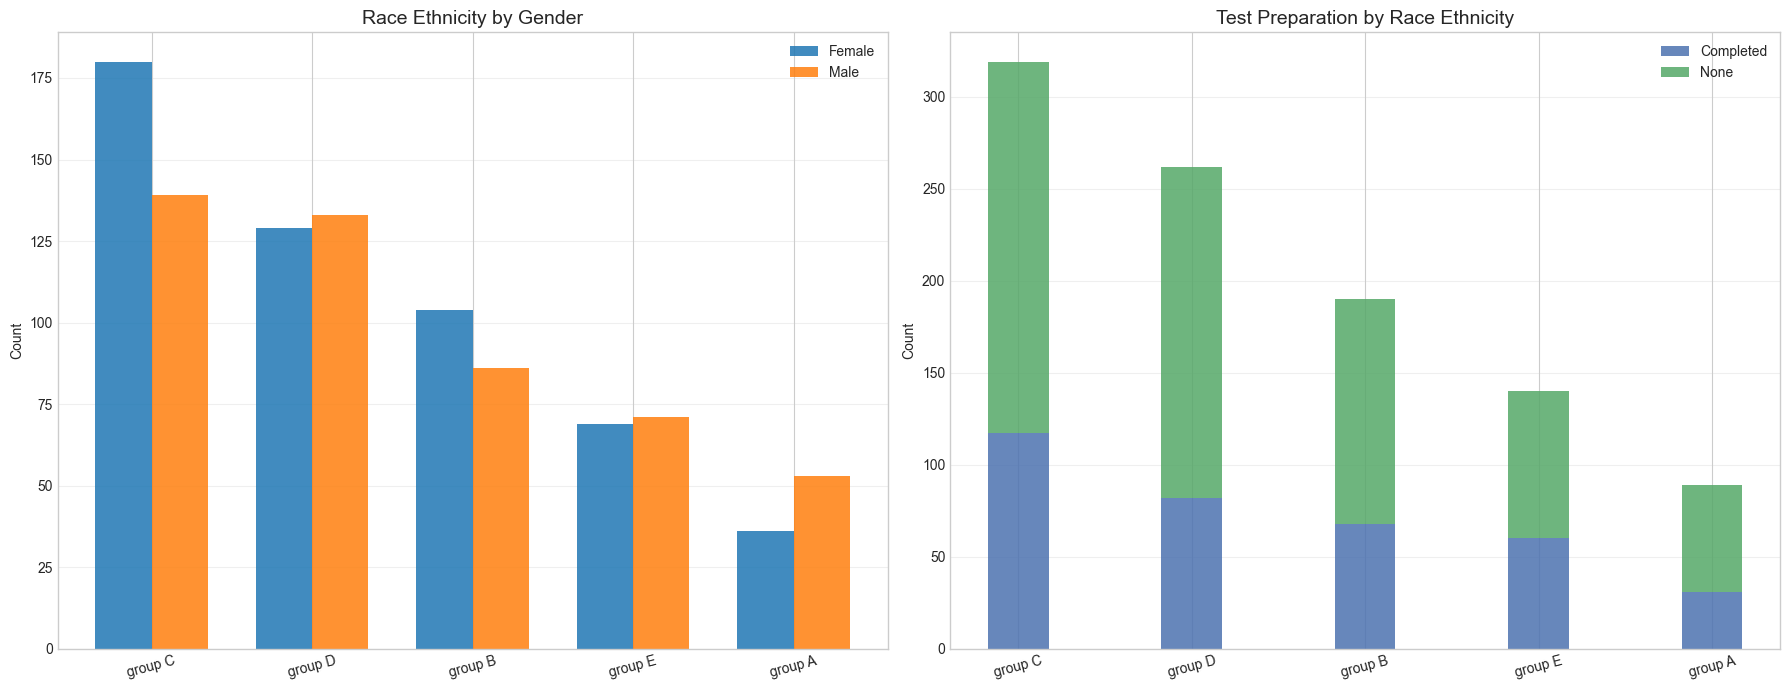

In [124]:
race_gender = df.groupby(['race_ethnicity', 'gender']).size().unstack(fill_value=0).reindex(index=race_order, columns=GENDER_ORDER)
race_gender_prop = race_gender.div(race_gender.sum(axis=1), axis=0)
test_prep = df.groupby(['race_ethnicity', 'test_preparation_course']).size().unstack(fill_value=0).reindex(index=race_order)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
x = np.arange(len(race_order))
width = 0.35
axes[0].bar(x - width/2, race_gender[GENDER_ORDER[0]], width, label=GENDER_ORDER[0].title(), color=GENDER_COLORS[0], alpha=0.85)
axes[0].bar(x + width/2, race_gender[GENDER_ORDER[1]], width, label=GENDER_ORDER[1].title(), color=GENDER_COLORS[1], alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(race_order, rotation=15)
axes[0].set_title('Race Ethnicity by Gender', fontsize=14)
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

bottom = np.zeros(len(race_order))
colors_tp = ['#4c72b0', '#55a868']
for idx, col in enumerate(test_prep.columns):
    axes[1].bar(x, test_prep[col], width, bottom=bottom, label=col.title(), color=colors_tp[idx], alpha=0.85)
    bottom += test_prep[col].values
axes[1].set_xticks(x)
axes[1].set_xticklabels(race_order, rotation=15)
axes[1].set_title('Test Preparation by Race Ethnicity', fontsize=14)
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

- Univariate: Group C is the largest; Group A is the smallest; others are comparable in size.
- Bivariate: Group C shows the highest central scores across math, reading, writing, and average; Groups A/E trail with wider spreads.
- Multivariate: Gender mix is fairly balanced within each group, with a slight female edge in C; test-prep participation is notably higher in Groups B and C than in A/E.

#### 6.2 Correlation

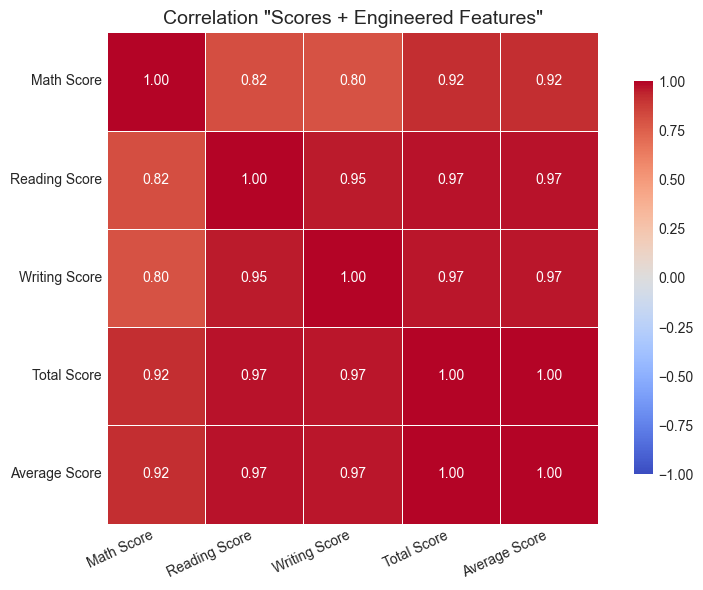

In [125]:

corr_features = ['math_score', 'reading_score', 'writing_score', 'total_score', 'average_score']
corr = df[corr_features].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={'shrink': 0.8},
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'fontsize': 10},
)
ax.set_xticklabels([c.replace('_', ' ').title() for c in corr_features], rotation=25, ha='right')
ax.set_yticklabels([c.replace('_', ' ').title() for c in corr_features], rotation=0)
ax.set_title('Correlation "Scores + Engineered Features"', fontsize=14)
plt.tight_layout()
plt.show()

### 7. Conclusions

- Standard lunch students score higher across all subjects; free/reduced lunch shows lower medians and wider spread, suggesting socioeconomic effect.
- Completing test prep lifts math/reading/writing medians for both genders; females remain ahead on language-heavy subjects while gaps narrow.
- Correlation is strongest between reading/writing and engineered `total_score`/`average_score`; math is slightly less tied to language scores but still pushes overall metrics.
- Lunch and test-prep should be considered key categorical features; `total_score` and `average_score` are useful engineered targets for ranking or bins.